<a href="https://colab.research.google.com/github/alexander-toschev/cv-course/blob/main/semantic/Practise_semantic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📖 Scene Graph Generation Mini-Project

## 1. Установка и импорты

In [1]:

!pip install torch torchvision matplotlib networkx -q

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import networkx as nx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.6 MB/s eta 0:00:00


## 2. Загрузка модели и данных

In [3]:

# Загружаем предобученный Faster R-CNN
model = fasterrcnn_resnet50_fpn(pretrained=True)
model = model.eval()

# Загружаем изображение (замени на свое при необходимости)
!wget https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg -O test_image.jpg
image = Image.open('/content/1056996866_0_0_3072_2048_1440x900_80_0_1_559f66459f2e83d342b7555b4cd13c59.jpg.webp').convert("RGB")
img_tensor = F.to_tensor(image).unsqueeze(0)



--2025-05-06 16:37:32--  https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99389 (97K) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]  97.06K  --.-KB/s    in 0.004s  

2025-05-06 16:37:32 (23.6 MB/s) - ‘test_image.jpg’ saved [99389/99389]



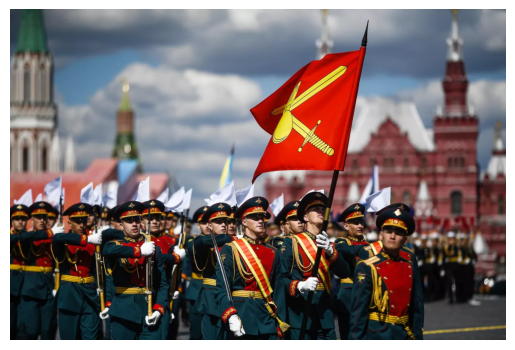

In [4]:
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()

## 3. Детекция объектов

In [18]:

# Детектируем объекты
with torch.no_grad():
    prediction = model(img_tensor)[0]

# Фильтрация объектов с высоким скором
threshold = 0.8
boxes = prediction['boxes'][prediction['scores'] > threshold]
labels = prediction['labels'][prediction['scores'] > threshold]

scores = prediction['scores'][prediction['scores'] > threshold]

# Названия классов COCO
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

# Выводим объекты
for idx, box in enumerate(boxes):
    print(f"Object {idx}: {COCO_INSTANCE_CATEGORY_NAMES[labels[idx]]} - Box: {box.tolist()}")


Object 0: person - Box: [920.6366577148438, 523.0812377929688, 1126.8795166015625, 900.0]
Object 1: person - Box: [6.560571670532227, 512.9732666015625, 124.10269165039062, 900.0]
Object 2: person - Box: [112.60171508789062, 521.1967163085938, 266.23358154296875, 898.4923095703125]
Object 3: person - Box: [720.2789306640625, 513.3212280273438, 924.2208862304688, 895.6126098632812]
Object 4: person - Box: [482.7043151855469, 525.344482421875, 625.0490112304688, 894.03662109375]
Object 5: person - Box: [229.94967651367188, 522.693603515625, 424.24591064453125, 894.5321655273438]
Object 6: person - Box: [575.568359375, 506.499267578125, 746.3851928710938, 896.6842041015625]
Object 7: knife - Box: [280.3024597167969, 191.27268981933594, 359.91497802734375, 536.1801147460938]
Object 8: person - Box: [1180.3193359375, 604.3424072265625, 1256.3416748046875, 806.089111328125]
Object 9: surfboard - Box: [665.4345703125, 46.19023132324219, 965.4144287109375, 637.2987060546875]
Object 10: person 

In [15]:
import numpy as np
# Порог расстояния, выше которого объекты считаются "far away"
DISTANCE_THRESHOLD = 400  # пиксели, подберите под свои данные

# Функция для определения отношения на основе координат
def determine_relation(box1, box2):
    center1 = ((box1[0] + box1[2]) / 2, (box1[1] + box1[3]) / 2)
    center2 = ((box2[0] + box2[2]) / 2, (box2[1] + box2[3]) / 2)

    dx = center2[0] - center1[0]
    dy = center2[1] - center1[1]
    distance = np.hypot(dx, dy)
    print(distance)

    if distance > DISTANCE_THRESHOLD:
        return None  # слишком далеко — нет связи

    if abs(dx) > abs(dy):
        return "right of" if dx > 0 else "left of"
    else:
        return "below" if dy > 0 else "above"

## 4. Построение сцено-графа

<ipython-input-15-951779d7064d>:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  distance = np.hypot(dx, dy)


tensor(958.4397)
tensor(834.3421)
tensor(201.6323)
tensor(469.8850)
tensor(696.6664)
tensor(362.9176)
tensor(784.9186)
tensor(194.6753)
tensor(424.4433)
tensor(133.5120)
tensor(958.4397)
tensor(124.1314)
tensor(756.9209)
tensor(488.5555)
tensor(261.7748)
tensor(595.6653)
tensor(427.0784)
tensor(1152.9996)
tensor(834.0721)
tensor(1091.6683)
tensor(834.3421)
tensor(124.1314)
tensor(632.8550)
tensor(364.4590)
tensor(137.6856)
tensor(471.6313)
tensor(369.9701)
tensor(1028.9233)
tensor(726.2108)
tensor(967.6011)
tensor(201.6323)
tensor(756.9209)
tensor(632.8550)
tensor(268.4241)
tensor(495.1695)
tensor(161.2987)
tensor(606.8359)
tensor(396.0814)
tensor(362.7867)
tensor(334.7478)
tensor(469.8850)
tensor(488.5555)
tensor(364.4590)
tensor(268.4241)
tensor(226.7814)
tensor(107.4059)
tensor(417.5388)
tensor(664.4690)
tensor(451.4328)
tensor(603.1552)
tensor(696.6664)
tensor(261.7748)
tensor(137.6856)
tensor(495.1695)
tensor(226.7814)
tensor(333.9529)
tensor(344.9573)
tensor(891.2393)
tensor(610.

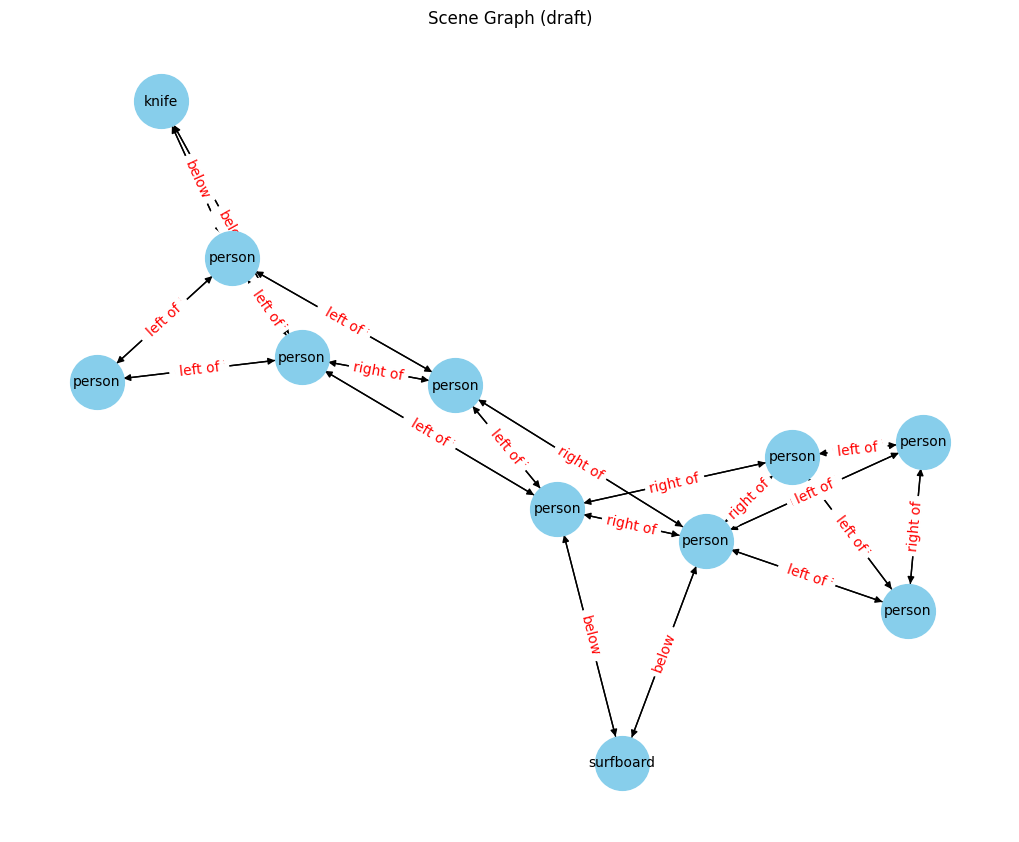

In [20]:

# Строим граф
G = nx.DiGraph()

# Добавляем объекты как узлы
for idx, label in enumerate(labels):
    G.add_node(idx, label=COCO_INSTANCE_CATEGORY_NAMES[label])

# Добавляем все возможные пары как ребра
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            relation = determine_relation(boxes[i], boxes[j])

            if relation:  # если не None
                G.add_edge(i, j, relation=relation)


# Визуализация
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
labels_node = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, with_labels=True, labels=labels_node, node_color='skyblue', node_size=1500, font_size=10, arrows=True)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title("Scene Graph (draft)")
plt.show()


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_image_with_boxes(image, boxes, labels, scores=None, threshold=0.5):
    """
    Рисует изображение с наложенными bounding boxes и метками.

    :param image: numpy-массив изображения (H, W, 3)
    :param boxes: список [x1, y1, x2, y2] для каждого объекта
    :param labels: список индексов классов (int)
    :param scores: список вероятностей для фильтрации (опционально)
    :param threshold: порог для фильтрации по вероятности
    """
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    for i, box in enumerate(boxes):
        if scores is not None and scores[i] < threshold:
            continue

        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1

        rect = patches.Rectangle((x1, y1), width, height, linewidth=2,
                                 edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

        label_text = COCO_INSTANCE_CATEGORY_NAMES[labels[i]]
        if scores is not None:
            label_text += f" ({scores[i]:.2f})"

        ax.text(x1, y1 - 5, label_text,
                fontsize=10, color='white',
                bbox=dict(facecolor='black', alpha=0.7, pad=2))

    plt.axis('off')
    plt.title("Detected Objects")
    plt.show()


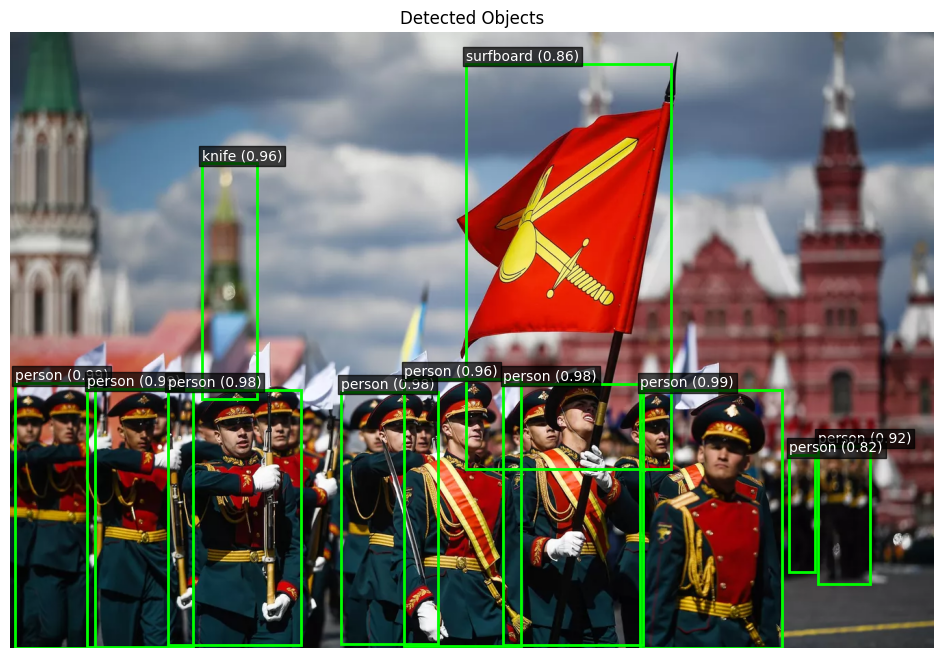

In [19]:
plot_image_with_boxes(image, boxes, labels, scores, threshold=0.5)